In [203]:
import requests
import pandas as pd
import re
import urllib
from tqdm import tqdm

# This notebook converts voting_id's to dataframes of votes for each period

In [204]:
with urllib.request.urlopen("https://raw.githubusercontent.com/Somon8/social_graphs_25/main/final-project/folketinget_votings_enriched.csv") as response:
    df_votings = pd.read_csv(response)

In [205]:
n_votes = len(df_votings['id_afstemning'].unique())
n_periods = df_votings['Period'].nunique()
print(f"There are {n_votes} unique votes in the dataset, across {n_periods} periods.")

There are 10304 unique votes in the dataset, across 7 periods.


In [206]:
# base_url = "https://oda.ft.dk/api/"
    
# n_votes = 500
# def get_voting_sessions_in_period():
#     # Get all voting ID´s in a specific period to pass to "get_voting_session_with_votes"
#     # voting_ids= [10375, 10376, 10377, 10378] #
#     voting_ids = range(10379-n_votes, 10379)
#     return voting_ids

def get_voting_sessions_in_period(period):
    votings_ids = df_votings[df_votings['Period'] == period]['id_afstemning'].unique() #Do i need to convert to list?
    print(f"Found {len(votings_ids)} votes in period {period}")
    return votings_ids

# def get_data_from_voting_session(voting_id):
#     data = DanishParliamentAPI().get_voting_session_details(voting_id)
#     vote_data = []
#     votes = data.get('Stemme')
#     for individual_vote in votes:
#         # return_data = individual_vote
#         # return_data = individual_vote.get('Aktør').get('biografi') #This is useful for finding the information about the person who voted.

#         politician_bio = individual_vote.get('Aktør').get('biografi')
#         politician_party = re.search('<party>([^<]+)</party>', politician_bio).group(1) #Extract the party
#         politician_name = individual_vote.get('Aktør').get('navn') #Find the name of who votes. We will use this for naming the nodes.
#         vote_type = individual_vote.get('typeid') #What did they vote?

#         vote_data.append((voting_id, politician_party, politician_name, vote_type)) #Will pass to DF instead, so no need for dict 
#     df = pd.DataFrame(vote_data, columns = ['voting_id', 'party', 'politician', 'vote_type'])
#     return df
        # print(vote_data)
    

################################################## All is out-commented, to use the DanishParliamentAPI instead.
# BASE_URL = "https://oda.ft.dk/api/"
request_session = requests.Session()

def get_voting_session_with_votes(voting_id, session = request_session):
    base_url = "https://oda.ft.dk/api/"
    all_votes = []
    skip = 0

    next_link = None

    while True:
        # params = {
        #     '$top':100
        #     ,'$skip' : skip
        #     # ,'$filter': f'id eq {voting_id}'
        #     ,'$expand': 'Stemme' #/Aktør
        # }

        url = f"{base_url}Afstemning({voting_id})/Stemme"
        # print(f"Base URL without params: {url}")
        if next_link:
            # print(f"THERE IS A NEXT LINK: {next_link}")
            response = session.get(next_link)
        else:
            # response = session.get(url, params=params) #Use session to reuse connections and make everything run faster
            response = session.get(url)
            # print(f"This is the URL with parameters: {response.url}")
            # response = session.get(url)

        if response.status_code != 200: #If the response is not ok print it and continue, no need to break the program.
            print(f"HTTP error for {voting_id}: ", response.status_code)
            print("Response text:", response.text)
            return None
        else:
            try:
                data = response.json()
            except ValueError:
                print("Error: Response is not valid JSON")
                print("Response text:", response.text)
                return None
        

        # print("Original_data", data)
        votes = data.get('value')
        next_link = data.get("odata.nextLink")
        # print("Next_link is ", next_link)
        # print("Value", votes)


        # votes = contained_data
        if not votes:
            # print("not votes????")
            break

        all_votes.extend(votes)
        if not next_link: #'https://oda.ft.dk/api/Afstemning(9700)/Stemme?$skip=100
            # print("No link found")
            break

        skip += 100
        # print("First loop done")

    return all_votes 

voting_id = 9700
data_from_voting_session = get_voting_session_with_votes(voting_id)


In [201]:
# voting_id = 9700#9799
# voting_id_2 = 9900#9798
# data_1 = get_voting_session_with_votes(voting_id)
# df_1 = get_data_from_voting_session(voting_id=voting_id, data_from_voting_session=data_1)
# data_2 = get_voting_session_with_votes(voting_id_2)
# df_2 = get_data_from_voting_session(voting_id=voting_id_2, data_from_voting_session=data_2)
# # pd.concat([df_1, df_2], axis = 1)
# df_1.compare(df_2)
# # df

In [208]:
# voting_period = 69
#Save it as a period
def get_and_save_df_from(voting_period):
    voting_sessions = get_voting_sessions_in_period(voting_period)
    all_votes_full_period = []
    for voting_id in tqdm(voting_sessions):
        votes_for_session = get_voting_session_with_votes(voting_id)
        all_votes_full_period.extend(votes_for_session)
    
    df = pd.DataFrame(all_votes_full_period)

    #Rename the columns to something usefull
    df.rename(columns={"id": "metadata_vote_id"
                       ,"typeid": "vote_type"
                       ,"afstemningid": "voting_id"
                       ,"opdateringsdato" : "metadata_opdateringsdato"
                       ,"aktørid" : "aktør_id"
                       }
                       , inplace= True
                       )

    df.to_csv(f"./voting-data/df_votes_p{voting_period}.csv", index = False)
    return df

for period in [70, 71]:
    # print(f'Now working on period {period}')
    df = get_and_save_df_from(period)

df.head(5)

Found 1838 votes in period 70


100%|██████████| 1838/1838 [02:22<00:00, 12.91it/s]


Found 1379 votes in period 71


100%|██████████| 1379/1379 [01:42<00:00, 13.43it/s]


,metadata_vote_id,vote_type,voting_id,aktør_id,metadata_opdateringsdato
0,2066805,1,9002,220,2022-11-16T13:09:09.15
1,2066806,1,9002,121,2022-11-16T13:09:09.15
2,2066807,1,9002,93,2022-11-16T13:09:09.15
3,2066808,1,9002,120,2022-11-16T13:09:09.15
4,2066809,1,9002,34,2022-11-16T13:09:09.15


In [209]:
df = pd.DataFrame()
for period in df_votings['Period'].unique():
    with urllib.request.urlopen(f"https://raw.githubusercontent.com/Somon8/social_graphs_25/main/final-project/voting-data/df_votes_p{period}.csv") as response:
        df_votes_from_period = pd.read_csv(response)
        df = pd.concat([df, df_votes_from_period])

df.to_csv(f"./voting-data/df_votes_all_periods.csv", index = False)

In [211]:
df

,voting_id,party,politician,vote_type
0,5973,Socialdemokratiet,Nicolai Wammen,1
1,5973,Socialdemokratiet,Henrik Sass Larsen,3
2,5973,Socialistisk Folkeparti,Holger K. Nielsen,1
3,5973,Danmarksdemokraterne,Peter Skaarup,1
4,5973,Venstre,Erling Bonnesen,1
...,...,...,...,...
29395,6269,Socialdemokratiet,Peder Sass,4
29396,6269,Dansk Folkeparti,Per Dalgaard,3
29397,6269,Socialdemokratiet,Pernille Blach Hansen,3
29398,6269,Uden for folketingsgrupperne,Peter Brixtofte,3


In [210]:
periods = [65, 66, 67, 68, 69, 70, 71]
for period in periods:
    with urllib.request.urlopen(f"https://raw.githubusercontent.com/Somon8/social_graphs_25/main/final-project/voting-data/df_votes_p{period}.csv") as response:
        df = pd.read_csv(response)
        n_unique = df["aktør_id"].nunique()
        print(f"Period {period} has {n_unique} unique politicians")


KeyError: 'aktør_id'

In [ ]:
period = 71
with urllib.request.urlopen(f"https://raw.githubusercontent.com/Somon8/social_graphs_25/main/final-project/voting-data/df_votes_p{period}.csv") as response:
    df = pd.read_csv(response)

representatives = df[["politician", "party"]].drop_duplicates() #126 unique in 

party_counts = (representatives.groupby(
    by = ["party"]
)
    .size()
    .rename("Member")
)

party_counts.head(20)

# Alternativet mangler 5
# Socialdemokratiet mangler 10
# LA mangler 10 el. 11

representatives[representatives["party"] == "Liberal Alliance"]
#LA har Ole Birk Olesen, Carsten Bach, Henrik Dahl og Alex Vanopslagh
#Mangler e.g. Alexandar Ryle

,politician,party
13,Ole Birk Olesen,Liberal Alliance
84,Carsten Bach,Liberal Alliance
89,Henrik Dahl,Liberal Alliance
35599,Alex Vanopslagh,Liberal Alliance


In [25]:
representatives[representatives["politician"] == "Alexander Ryle"] #NOPE
representatives[representatives["politician"] == "Pernille Vermund"] #NOPE
representatives[representatives["politician"] == "Alex Vanopslagh"]

,politician,party
35599,Alex Vanopslagh,Liberal Alliance


In [26]:
representatives

,politician,party
0,Nicolai Wammen,Socialdemokratiet
1,Alex Ahrendtsen,Dansk Folkeparti
2,Søren Espersen,Danmarksdemokraterne
3,Astrid Krag,Socialdemokratiet
4,Pia Olsen Dyhr,Socialistisk Folkeparti
...,...,...
112599,Mona Juul,Det Konservative Folkeparti
118566,Yildiz Akdogan,Socialdemokratiet
121599,Henrik Møller,Socialdemokratiet
130097,Signe Munk,Socialistisk Folkeparti


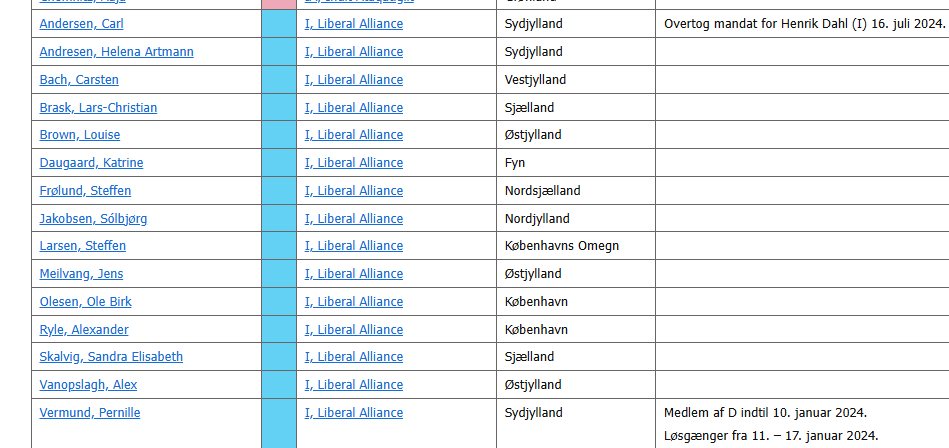

In [28]:
#Vi kan se at Alexander Ryle har stemt ved  Afstemning nr. 461, 2024-25, 104. Møde, 2025-06-04, 10:00
with urllib.request.urlopen("https://raw.githubusercontent.com/Somon8/social_graphs_25/main/final-project/folketinget_votings_enriched.csv") as response:
    df_votings = pd.read_csv(response)
df_votings


,id_afstemning,nummer_afstemning,konklusion,vedtaget,kommentar,mødeid,typeid_afstemning,sagstrinid,opdateringsdato_afstemning,Sagstrin,...,Møde.nummer,Møde.dagsordenurl,Møde.starttidsbemærkning,Møde.offentlighedskode,Møde.dato,Møde.statusid,Møde.typeid,Møde.periodeid,Møde.opdateringsdato,Period
0,1,411,"Vedtaget\n\n108 stemmer for forslaget (V, S, D...",True,NaN,17,2,NaN,2014-09-09T09:05:59.653,NaN,...,104.0,NaN,NaN,O,2014-09-09 09:00:00,2,1,32,2014-11-12T09:08:46.54,68
1,2,412,"Vedtaget\n\n98 stemmer for forslaget (V, S, DF...",True,NaN,18,1,4849.0,2014-09-09T09:25:05.717,"{'id': 4849, 'titel': '3. behandling', 'dato':...",...,105.0,NaN,5 min. efter afslutningen af møde nr. 104,O,2014-09-09 09:15:00,2,1,32,2014-11-12T09:11:13.353,68
2,3,1,"Vedtaget\n\n59 stemmer for forslaget (S, RV, S...",True,NaN,41,3,17351.0,2018-01-24T16:46:33.99,"{'id': 17351, 'titel': 'Behandling', 'dato': '...",...,3.0,NaN,10.00,O,2012-10-04 10:00:00,2,1,31,2023-03-09T11:47:45.12,68
3,4,7,"Vedtaget\n\n72 stemmer for forslaget (S, DF, R...",True,NaN,156,1,18370.0,2018-01-25T10:25:25.64,"{'id': 18370, 'titel': '3. behandling', 'dato'...",...,15.0,NaN,Mødet starter umiddelbart efter møde 14 er slut.,O,2012-11-06 00:00:00,2,1,31,2023-03-09T11:46:27.79,68
4,5,412,"Vedtaget\n\n98 stemmer for forslaget (V, S, DF...",True,NaN,18,1,4849.0,2017-08-10T12:57:52.27,"{'id': 4849, 'titel': '3. behandling', 'dato':...",...,105.0,NaN,5 min. efter afslutningen af møde nr. 104,O,2014-09-09 09:15:00,2,1,32,2014-11-12T09:11:13.353,68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10299,10376,467,"Vedtaget\nFor stemte 105 (S, V, DD, SF, LA, M,...",True,NaN,15164,3,266833.0,2025-06-11T15:00:50.97,"{'id': 266833, 'titel': 'Behandling', 'dato': ...",...,105.0,NaN,NaN,O,2025-06-11 09:00:00,2,1,163,2025-09-08T10:10:26.747,71
10300,10377,532,"Vedtaget\nFor stemte 91 (S, V, DD, SF, LA, M, ...",True,Ved en fejl blev der stemt fra Peter Juel-Jens...,14602,1,267148.0,2025-09-09T12:30:12.467,"{'id': 267148, 'titel': 'Eventuelt: 3. behandl...",...,110.0,NaN,NaN,O,2025-09-09 09:00:00,2,1,163,2025-09-10T08:47:28.683,71
10301,10378,533,"Vedtaget\nFor stemte 93 (S, V, DD, SF, LA, M, ...",True,Grundet en teknisk fejl kunne der ikke stemmes...,15399,1,267397.0,2025-09-30T14:56:15.043,"{'id': 267397, 'titel': '3. behandling', 'dato...",...,112.0,NaN,NaN,O,2025-09-30 13:00:00,2,1,163,2025-10-01T09:12:40.153,71
10302,10379,2,"Vedtaget\nFor stemte 59 (S, V, M, JF, Jeppe Sø...",True,NaN,15443,3,268868.0,2025-10-10T11:45:43.137,"{'id': 268868, 'titel': 'Behandling', 'dato': ...",...,3.0,NaN,NaN,O,2025-10-09 08:00:00,2,1,165,2025-10-10T10:51:47.74,71


In [32]:
df_177 = df_votings[(df_votings['nummernumerisk'] == 177) & (df_votings['Period']==71)]

In [ ]:
df_177

,id_afstemning,nummer_afstemning,konklusion,vedtaget,kommentar,mødeid,typeid_afstemning,sagstrinid,opdateringsdato_afstemning,Sagstrin,...,Møde.nummer,Møde.dagsordenurl,Møde.starttidsbemærkning,Møde.offentlighedskode,Møde.dato,Møde.statusid,Møde.typeid,Møde.periodeid,Møde.opdateringsdato,Period
9694,9771,436,Forslaget blev forkastet. For stemte 4 (DF og ...,False,NaN,13786,4,255248.0,2024-05-30T13:30:45.527,"{'id': 255248, 'titel': '2. behandling', 'dato...",...,102.0,NaN,NaN,O,2024-05-30 10:00:00,2,1,160,2025-09-11T13:59:17.337,71
9695,9772,437,Forslaget blev forkastet. For stemte 4 (DF og ...,False,NaN,13786,4,255248.0,2024-05-30T13:31:11.267,"{'id': 255248, 'titel': '2. behandling', 'dato...",...,102.0,NaN,NaN,O,2024-05-30 10:00:00,2,1,160,2025-09-11T13:59:17.337,71
9696,9773,438,"Forslaget blev forkastet. For stemte 19 (DD, K...",False,NaN,13786,4,255248.0,2024-05-30T13:31:35.167,"{'id': 255248, 'titel': '2. behandling', 'dato...",...,102.0,NaN,NaN,O,2024-05-30 10:00:00,2,1,160,2025-09-11T13:59:17.337,71
9697,9774,439,"Forslaget blev forkastet. For stemte 19 (DD, K...",False,NaN,13786,4,255248.0,2024-05-30T13:31:58.483,"{'id': 255248, 'titel': '2. behandling', 'dato...",...,102.0,NaN,NaN,O,2024-05-30 10:00:00,2,1,160,2025-09-11T13:59:17.337,71
9698,9775,440,Forslaget blev forkastet. For stemte 4 (DF og ...,False,NaN,13786,4,255248.0,2024-05-30T13:32:18.71,"{'id': 255248, 'titel': '2. behandling', 'dato...",...,102.0,NaN,NaN,O,2024-05-30 10:00:00,2,1,160,2025-09-11T13:59:17.337,71
9699,9776,441,Forslaget blev forkastet. For stemte 4 (DF og ...,False,NaN,13786,4,255248.0,2024-05-30T13:32:49.52,"{'id': 255248, 'titel': '2. behandling', 'dato...",...,102.0,NaN,NaN,O,2024-05-30 10:00:00,2,1,160,2025-09-11T13:59:17.337,71
9700,9777,442,Forslaget blev forkastet. For stemte 11 (Kim E...,False,Ved en fejl stemte Kim Edberg Andersen (DD) fo...,13786,4,255248.0,2024-06-24T09:38:59.52,"{'id': 255248, 'titel': '2. behandling', 'dato...",...,102.0,NaN,NaN,O,2024-05-30 10:00:00,2,1,160,2025-09-11T13:59:17.337,71
9701,9778,443,Forslaget blev forkastet. For stemte 4 (DF og ...,False,NaN,13786,4,255248.0,2024-05-30T13:33:53.563,"{'id': 255248, 'titel': '2. behandling', 'dato...",...,102.0,NaN,NaN,O,2024-05-30 10:00:00,2,1,160,2025-09-11T13:59:17.337,71
9702,9779,444,Forslaget blev forkastet. For stemte 5 (Søren ...,False,Ved en fejl stemte Søren Espersen (DD) imod fo...,13786,4,255248.0,2024-05-30T19:07:35.253,"{'id': 255248, 'titel': '2. behandling', 'dato...",...,102.0,NaN,NaN,O,2024-05-30 10:00:00,2,1,160,2025-09-11T13:59:17.337,71
9703,9780,445,Forslaget blev forkastet. For stemte 4 (DF og ...,False,NaN,13786,4,255248.0,2024-05-30T13:34:46.59,"{'id': 255248, 'titel': '2. behandling', 'dato...",...,102.0,NaN,NaN,O,2024-05-30 10:00:00,2,1,160,2025-09-11T13:59:17.337,71


In [41]:
grouped_obs = (
    df_votings.groupby(
        by = ['Møde.id']
    ).size()
    .rename("Observations")
)

grouped_obs.sort_values(ascending= False)

Møde.id
5360     173
11839     95
13788     94
2841      93
5602      77
        ... 
41         1
15         1
15399      1
15443      1
15446      1
Name: Observations, Length: 1015, dtype: int64